In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.1.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install moviepy


[notice] A new release of pip is available: 24.1.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install tensorflow opencv-python


[notice] A new release of pip is available: 24.1.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, BatchNormalization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score, precision_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import cv2
from sklearn.utils import shuffle

In [5]:
videos = []
classes = []

data = '../videos'
# Load the data
for filename in os.listdir(data):
    if filename.endswith('.mp4'):
        videos.append(filename)
        normalOrAbnormal = filename.split('_')[0]
        if normalOrAbnormal == 'Normal':
            classes.append(0)
        else:
            classes.append(1)

df = pd.DataFrame({'Video': videos, 'Class': classes})
df['videos'] = videos
df['classes'] = classes

In [6]:
print(df['Class'].value_counts())

Class
1    309
0     51
Name: count, dtype: int64


In [7]:
# Parámetros
IMG_SIZE = 112  # Tamaño del frame
SEQUENCE_LENGTH = 100  # Número de frames por video

# Función para cargar y procesar videos
def load_video(video_path, max_frames=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)
    cap.release()

    # Si el video tiene menos frames, repite los últimos
    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.array(frames, dtype=np.float32) / 255.0  # Normaliza los valores

In [8]:
def augment_video(video):
    """ Aplica transformaciones simples a un video (flip, brillo, rotación) """
    augmented_videos = []
    
    # Invertir horizontalmente
    flipped = np.array([cv2.flip(frame, 1) for frame in video])
    augmented_videos.append(flipped)

    # Aumentar brillo
    brighter = np.array([cv2.convertScaleAbs(frame, alpha=1.2, beta=30) for frame in video])
    augmented_videos.append(brighter)

    # Rotación pequeña
    rows, cols, _ = video[0].shape
    M = cv2.getRotationMatrix2D((cols//2, rows//2), 10, 1)
    rotated = np.array([cv2.warpAffine(frame, M, (cols, rows)) for frame in video])
    augmented_videos.append(rotated)

    return augmented_videos

def create_dataset(data_dir):
    normalizedVideos = []
    labels = []

    for video, label in zip(df['videos'], df['classes']):
        newVideo = load_video(os.path.join(data_dir, video))
        print(f"Video cargado: {video}, {newVideo.shape}, {label}")

        # Guardar el video original
        normalizedVideos.append(newVideo)
        labels.append(label)

        # Aplicar aumentación solo a la clase 0
        if label == 0:
            augmented_videos = augment_video(newVideo)
            for aug_video in augmented_videos:
                normalizedVideos.append(aug_video)
                labels.append(0)

    # Convertir a numpy arrays
    normalizedVideos = np.array(normalizedVideos)
    labels = np.array(labels)

    # Mezclar para evitar que los datos aumentados queden juntos
    normalizedVideos, labels = shuffle(normalizedVideos, labels, random_state=42)

    return normalizedVideos, labels
# Directorio de los datos
DATASET_PATH = "../videos"
videos, labels = create_dataset(DATASET_PATH)
print(f"Dataset cargado: {videos.shape}, {labels.shape}")

# Dividir en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(videos, labels, test_size=0.2, random_state=42)

Video cargado: Burglary001_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary002_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary003_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary004_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary006_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary007_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary008_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary009_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary010_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary011_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary012_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary013_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary014_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary015_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary016_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary017_x264.mp4, (100, 112, 112, 3), 1
Video cargado: Burglary018_x264.mp4, (100, 112, 112, 3),

In [9]:
# Crear un modelo 3D CNN
def create_3d_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        tf.keras.layers.Conv3D(64, kernel_size=(3, 3, 3), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        tf.keras.layers.Conv3D(128, kernel_size=(3, 3, 3), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Crear el modelo
input_shape = (SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
num_classes = len(np.unique(labels))
model = create_3d_cnn(input_shape, num_classes)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 98, 110, 110,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 49, 55, 55, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 47, 53, 53, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 23, 26, 26, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 21, 24, 24,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 10, 12, 12,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 184320)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,593,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,872,642 (91.07 MB)

 Trainable params: 23,872,642 (91.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#earlyStopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)

# Entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1,
    batch_size=16,
    #callbacks=[earlyStopping]
)

 2/26 ━━━━━━━━━━━━━━━━━━━━ 2:03:10 308s/step - accuracy: 0.4531 - loss: 5.3755

KeyboardInterrupt: 

In [ ]:
# Evaluar el modelo
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Pérdida: {loss}, Precisión: {accuracy}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 11s/step - accuracy: 0.8446 - loss: 0.5246
Pérdida: 0.5173876881599426, Precisión: 0.8611111044883728


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.86      1.00      0.93        62

    accuracy                           0.86        72
   macro avg       0.43      0.50      0.46        72
weighted avg       0.74      0.86      0.80        72



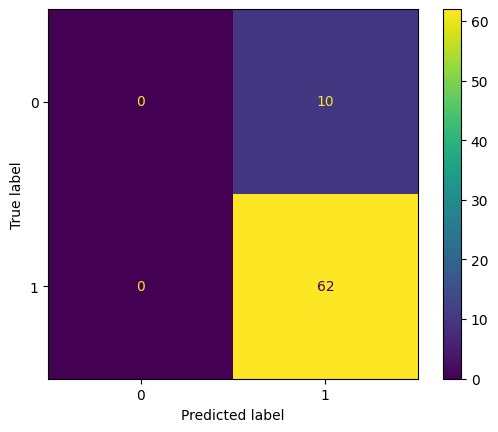

In [ ]:
# reporte de clasificación
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels))
disp.plot()

# Guardar el modelo
model.save('modelSuspicious.h5')